In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

import scanpy as sc
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white")


In [3]:
from pandas.errors import PerformanceWarning


In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=PerformanceWarning)


In [5]:
import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)


In [6]:
import sys
print(sys.executable)


C:\Users\PC\anaconda3\envs\bioinfo\python.exe


In [7]:
import gzip

path = "data/GSE131907_Lung_Cancer_raw_UMI_matrix.txt.gz"

with gzip.open(path, "rt") as f:
    for i in range(5):
        print(f.readline().rstrip()[:200])


Index	AAACCTGAGAAACCGC_LN_05	AAACCTGAGAAACGCC_NS_13	AAACCTGAGAAGGTGA_LUNG_N18	AAACCTGAGACAAAGG_LUNG_N18	AAACCTGAGACATAAC_LN_04	AAACCTGAGACCTTTG_LUNG_N30	AAACCTGAGACGACGT_LUNG_T09	AAACCTGAGACGACGT_LUNG
A1BG	0	0	0	0	0	0	0	0	0	0	0	0	0	1	0	0	1	0	0	0	0	3	0	0	0	1	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	1	1	0	0	0	1	0	0	0	0	0	0	0	0	0	0	0	2	0	0	1	0	0	0	0	0	0	0	0	1	0	0	0	0	0	0	0	0	0	0	0	1	0	0	0
A1BG-AS1	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	1	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0
A1CF	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0
A2M	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	2	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	22	0	0	0	0	0	0	0	0	0	1	0	0	0	0	1	0	0	0	0	0	0	0	6	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0

In [8]:
import os
print("CWD:", os.getcwd())
print("mtx_export exists:", os.path.exists("./data/mtx_export"))
print("files:", os.listdir("./data/mtx_export")[:10])


CWD: C:\Users\PC\OneDrive\Documents\Bioinformatics\tcga-lung-immune-evasion-scRNAseq
mtx_export exists: True
files: ['barcodes.tsv', 'genes.tsv', 'matrix.mtx']


In [9]:
import scanpy as sc
import pandas as pd

adata = sc.read_mtx("./data/mtx_export/matrix.mtx").T  # komórki jako wiersze
genes = pd.read_csv("./data/mtx_export/genes.tsv", header=None, sep="\t")
barcodes = pd.read_csv("./data/mtx_export/barcodes.tsv", header=None, sep="\t")

adata.var_names = genes[0].astype(str).values
adata.obs_names = barcodes[0].astype(str).values
adata.var_names_make_unique()

adata



AnnData object with n_obs × n_vars = 208506 × 29634

In [10]:
import scanpy as sc
import numpy as np
import pandas as pd

sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=100, facecolor="white")


In [11]:
genes = pd.read_csv("data/mtx_export/genes.tsv", header=None, sep="\t")
barcodes = pd.read_csv("data/mtx_export/barcodes.tsv", header=None, sep="\t")


adata.var_names = genes[0].values
adata.obs_names = barcodes[0].values

adata


AnnData object with n_obs × n_vars = 208506 × 29634

In [12]:

adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

adata.obs.head()


,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
AAACCTGAGAAACCGC_LN_05,1690,19928.0,43.0,0.215777
AAACCTGAGAAACGCC_NS_13,611,1382.0,171.0,12.373372
AAACCTGAGAAGGTGA_LUNG_N18,1113,3214.0,106.0,3.298071
AAACCTGAGACAAAGG_LUNG_N18,1100,2990.0,133.0,4.448161
AAACCTGAGACATAAC_LN_04,948,3880.0,76.0,1.958763


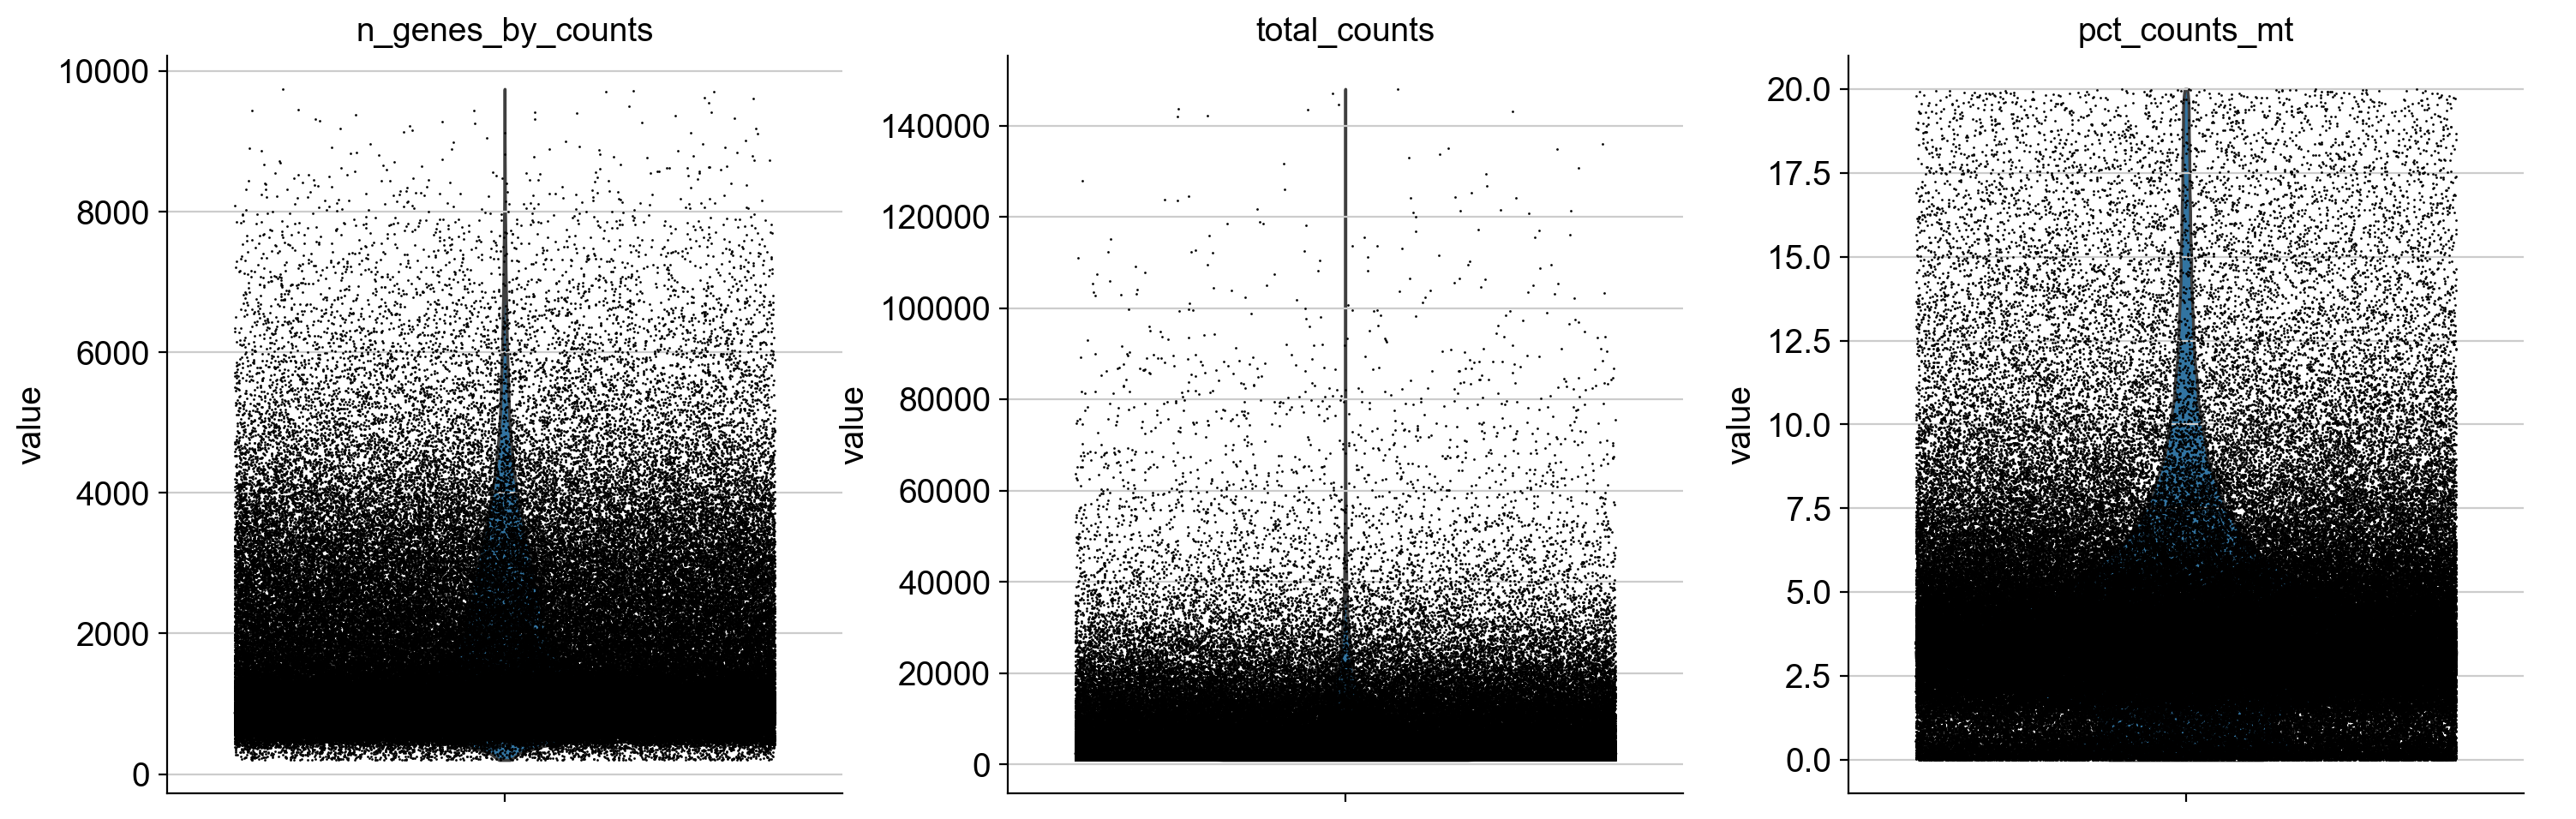

In [13]:
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
             jitter=0.4, multi_panel=True)


In [14]:
adata = adata[adata.obs.n_genes_by_counts > 300, :]
adata = adata[adata.obs.n_genes_by_counts < 6000, :]
adata = adata[adata.obs.pct_counts_mt < 12, :]


In [15]:
adata


View of AnnData object with n_obs × n_vars = 199612 × 29634
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

normalizing counts per cell
    finished (0:00:07)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:02:24)
computing neighbors
    using 'X_pca' with n_pcs = 30


C:\Users\PC\anaconda3\envs\bioinfo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:02:12)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:06:12)


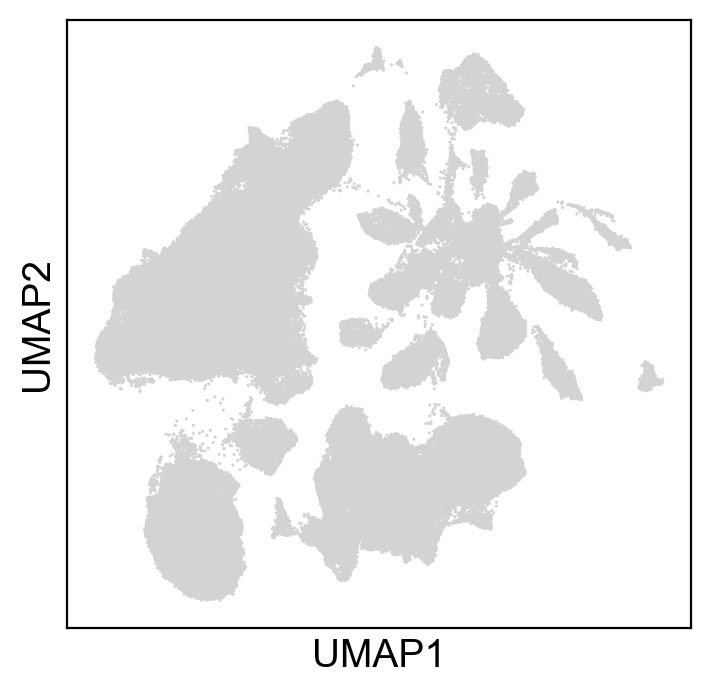

In [16]:
import scanpy as sc

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
sc.pl.umap(adata, size=5)


In [17]:
import sys
import skmisc
import scanpy as sc
print(sys.executable)
print("OK")


C:\Users\PC\anaconda3\envs\bioinfo\python.exe
OK


In [18]:
adata.write("results/adata_after_hvg.h5ad")


In [19]:
with open("data/mtx_export/matrix.mtx", "r", encoding="utf-8", errors="ignore") as f:
    for _ in range(5):
        print(f.readline().rstrip())


%%MatrixMarket matrix coordinate integer general
%
29634 208506 331860266
1 14 1
1 17 1


In [20]:
import os
print("CWD:", os.getcwd())
print(os.listdir("./data/mtx_export"))


CWD: C:\Users\PC\OneDrive\Documents\Bioinformatics\tcga-lung-immune-evasion-scRNAseq
['barcodes.tsv', 'genes.tsv', 'matrix.mtx']


In [21]:
import scanpy as sc
import pandas as pd

adata = sc.read_mtx("data/mtx_export/matrix.mtx").T
genes = pd.read_csv("data/mtx_export/genes.tsv", header=None, sep="\t")
barcodes = pd.read_csv("data/mtx_export/barcodes.tsv", header=None, sep="\t")

adata.var_names = genes[0].astype(str).values
adata.obs_names = barcodes[0].astype(str).values
adata.var_names_make_unique()

adata


MemoryError: Unable to allocate 1.24 GiB for an array with shape (331860266,) and data type int32

In [ ]:
adata.write("results/adata_raw.h5ad")


In [ ]:
import numpy as np
import scanpy as sc

adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

adata.obs.head()


In [ ]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)


In [ ]:
adata = adata[adata.obs.n_genes_by_counts > 300, :]
adata = adata[adata.obs.n_genes_by_counts < 6000, :]
adata = adata[adata.obs.pct_counts_mt < 12, :]

adata


In [ ]:
adata.write("results/adata_qc_filtered.h5ad")


In [ ]:
import scanpy as sc
import numpy as np
sc.pp.subsample(adata, n_obs=30000, random_state=42)

adata


In [ ]:
adata.write("results/adata_30k.h5ad")


In [ ]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")


In [ ]:
adata = adata[:, adata.var.highly_variable].copy()
adata


In [ ]:
adata.write("results/adata_hvg_30k.h5ad")


In [ ]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack")


In [ ]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)


In [ ]:
sc.tl.umap(adata)
sc.pl.umap(adata, size=6)


In [ ]:
import scanpy as sc

adata = sc.read_h5ad("results/adata_30k.h5ad")
adata


In [ ]:
sc.pl.umap(adata, color="leiden", size=6)


In [ ]:
adata.obsm_keys()


In [ ]:
import scanpy as sc

sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)

sc.pl.umap(adata, color="leiden", size=6)


In [ ]:
import scanpy as sc

adata = sc.read_h5ad("results/adata_hvg_30k.h5ad")

if "X_pca" not in adata.obsm_keys():
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, svd_solver="arpack")

sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)

sc.pl.umap(adata, color="leiden", size=6)


In [ ]:
adata.write("results/adata_leiden_30k_FINAL.h5ad")


In [ ]:
sc.pl.umap(adata, color="leiden", size=6, save="_leiden_30k.png")


In [ ]:
import scanpy as sc

sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)


In [ ]:
import pandas as pd

markers = sc.get.rank_genes_groups_df(adata, group=None)
markers.to_csv("results/leiden_markers_wilcoxon.csv", index=False)
markers.head()


In [ ]:
marker_genes = {
    "T cells": ["CD3D", "CD3E", "TRAC"],
    "CD8 T": ["CD8A", "CD8B", "GZMB", "NKG7"],
    "CD4 T": ["IL7R", "CCR7", "LTB"],
    "B cells": ["MS4A1", "CD79A", "CD74"],
    "Plasma": ["MZB1", "XBP1", "JCHAIN"],
    "Myeloid": ["LYZ", "LST1", "S100A8", "S100A9"],
    "Macrophage": ["C1QA", "C1QB", "C1QC", "APOE"],
    "DC": ["FCER1A", "CLEC10A"],
    "NK": ["NKG7", "GNLY", "PRF1"],
    "Endothelial": ["PECAM1", "VWF", "KDR"],
    "Fibroblast": ["COL1A1", "COL1A2", "DCN", "LUM"],
    "Epithelial/Tumor": ["EPCAM", "KRT19", "KRT8", "KRT18"],
}

sc.pl.umap(adata, color=sum(marker_genes.values(), []), ncols=4, size=8)


In [ ]:
adata.write("results/adata_umap_leiden_30k.h5ad")


In [ ]:
adata.var_names[:20]


In [ ]:
[ g for g in ["CD3D","TRAC","MS4A1","LYZ","EPCAM","PECAM1","COL1A1"] if g in adata.var_names ]


In [ ]:
import pandas as pd

genes = pd.read_csv("./data/mtx_export/genes.tsv", header=None, sep="\t")
genes.head()


In [ ]:
import scanpy as sc

adata_hvg = sc.read_h5ad("results/adata_hvg_30k.h5ad")   
adata_full = sc.read_h5ad("results/adata_30k.h5ad")      

In [ ]:
import scanpy as sc

adata = sc.read_h5ad("results/adata_hvg_30k.h5ad")
adata


In [ ]:
sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, svd_solver="arpack")

sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)

sc.tl.umap(adata)

sc.tl.leiden(adata, resolution=0.5)

sc.pl.umap(adata, color="leiden", size=6)


In [ ]:
adata.write("results/adata_hvg_30k_with_umap_leiden.h5ad")


In [ ]:
import scanpy as sc

sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)


In [ ]:
import scanpy as sc

sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)


In [ ]:
import pandas as pd
markers = sc.get.rank_genes_groups_df(adata, group=None)
markers.to_csv("results/leiden_markers_wilcoxon_hvg30k.csv", index=False)
markers.head()


In [ ]:
adata.obs["celltype"] = adata.obs["leiden"].astype(str)

sc.pl.umap(adata, color="celltype", size=6, legend_loc="on data")


In [ ]:
marker_dict = {
    "T_cells": ["CD3D","CD3E","TRAC","IL7R"],
    "CD8_cytotoxic": ["NKG7","GNLY","PRF1","GZMB"],
    "B_cells": ["MS4A1","CD79A","CD74"],
    "Plasma": ["MZB1","JCHAIN","IGKC"],
    "Myeloid_Macrophage": ["LYZ","LST1","S100A8","S100A9","FCGR3A"],
    "Dendritic": ["FCER1A","CST3"],
    "NK_cells": ["NCR1","KLRD1"],
    "Fibroblast": ["COL1A1","COL1A2","DCN","LUM"],
    "Endothelial": ["PECAM1","VWF","KDR"],
    "Epithelial_Tumor": ["EPCAM","KRT8","KRT18","KRT19","MUC1"]
}

for group, genes in marker_dict.items():
    genes = [g for g in genes if g in adata.var_names]
    if len(genes) > 0:
        sc.pl.umap(adata, color=genes, ncols=4, size=7, title=group)


In [ ]:
sc.pl.umap(adata, color=["leiden"], size=6)


In [ ]:
adata.obs.groupby("leiden").size()


In [ ]:
sc.pl.umap(adata, color=["GZMB","GNLY"], size=6)


In [ ]:
adata.obs["celltype"] = "Unknown"
adata.obs.loc[adata.obs["leiden"] == "X", "celltype"] = "CD8/NK cytotoxic"


In [ ]:
sc.pl.umap(adata, color=["EPCAM","KRT8","KRT18","KRT19","MUC1"], ncols=3, size=7)


In [ ]:
sc.pl.umap(adata, color="leiden", size=6)


In [ ]:
sc.pl.umap(adata, color="EPCAM", size=6)


In [ ]:
tumor_clusters = ["7","8","10","11"]

adata.obs["celltype"] = "Other"
adata.obs.loc[adata.obs["leiden"].isin(tumor_clusters), "celltype"] = "Tumor epithelial"


In [ ]:
sc.pl.umap(adata, color="celltype", size=6)


In [ ]:
sc.pl.umap(adata, color=["CD274","PDCD1","CTLA4","LAG3","TIGIT"], ncols=3, size=7)


In [ ]:
import scanpy as sc

adata_full = sc.read_h5ad("results/adata_30k.h5ad")


In [ ]:

adata_full.obsm["X_umap"] = adata.obsm["X_umap"].copy()
adata_full.obs["leiden"] = adata.obs["leiden"].copy()
adata_full.obs["celltype"] = adata.obs["celltype"].copy()


In [ ]:
[g for g in ["CD274","PDCD1","CTLA4","LAG3","TIGIT"] if g in adata_full.var_names]


In [ ]:
sc.pl.umap(
    adata_full,
    color=["CD274","PDCD1","CTLA4","LAG3","TIGIT","celltype"],
    ncols=3,
    size=7
)


In [ ]:
adata_full.write("results/adata_full_with_umap_leiden_celltype.h5ad")


In [ ]:
[x for x in adata_full.var_names if "CD274" in x or "PDCD1" in x][:20]


In [ ]:
[g for g in ["CD274","PDCD1","CTLA4","LAG3","TIGIT"] if g in adata_full.var_names]


In [ ]:
sc.pl.umap(
    adata_full,
    color=["CD274","celltype"],
    ncols=2,
    size=7
)


In [ ]:
sc.pl.umap(
    adata_full,
    color=["PDCD1","CTLA4","LAG3","TIGIT"],
    ncols=2,
    size=7
)


In [ ]:
sc.pl.umap(adata_full, color="PDCD1LG2", size=7)


In [ ]:
sc.pl.umap(
    adata_full,
    color=["HLA-A","HLA-B","HLA-C","B2M"],
    ncols=2,
    size=7
)


In [ ]:
sc.pl.umap(
    adata_full,
    color=["CD68","CD163","MRC1","IL10","TGFB1"],
    ncols=2,
    size=7
)


In [ ]:
sc.tl.rank_genes_groups(adata_full, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata_full, n_genes=15, sharey=False)


In [ ]:
import scanpy as sc

sc.pp.normalize_total(adata_full, target_sum=1e4)
sc.pp.log1p(adata_full)


In [ ]:
adata_full.raw = adata_full


In [ ]:
sc.tl.rank_genes_groups(adata_full, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata_full, n_genes=10, sharey=False)


In [ ]:
import scanpy as sc

sc.pp.normalize_total(adata_full, target_sum=1e4)
sc.pp.log1p(adata_full)


In [ ]:
import scanpy as sc
adata_full.raw = adata_full.copy()
sc.pp.normalize_total(adata_full, target_sum=1e4)
sc.pp.log1p(adata_full)


In [ ]:
sc.tl.rank_genes_groups(adata_full, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata_full, n_genes=15, sharey=False)


In [ ]:
sc.tl.rank_genes_groups(adata_full, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata_full, n_genes=15, sharey=False)


In [ ]:
sc.get.rank_genes_groups_df(adata_full, group="0").head(20)


In [ ]:
adata_full.obs["celltype"] = "Other"
adata_full.obs.loc[adata_full.obs["leiden"] == "0", "celltype"] = "T cells"


In [ ]:
sc.pl.umap(adata_full, color="celltype", legend_loc="on data")


In [ ]:
sc.get.rank_genes_groups_df(adata_full, group="1").head(20)


In [ ]:
for i in adata_full.obs["leiden"].cat.categories:
    df = sc.get.rank_genes_groups_df(adata_full, group=i)
    if any(g in df["names"].values for g in ["PDCD1","CTLA4","LAG3","TIGIT"]):
        print("cluster", i)
        print(df.head(15))
        print("-------------")


In [ ]:
checkpoint_genes = ["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2","TOX"]

for i in adata_full.obs["leiden"].cat.categories:
    cells = adata_full[adata_full.obs["leiden"] == i]
    expr = cells[:, checkpoint_genes].X.mean(axis=0)
    print("cluster", i, dict(zip(checkpoint_genes, expr)))


In [ ]:
sc.pl.umap(
    adata_full,
    color=["PDCD1","LAG3","TIGIT","HAVCR2","TOX"],
    ncols=3,
    vmax="p99"
)


In [ ]:
sc.pl.umap(adata_full, color=["CD3D","CD8A","CD4","FOXP3"], ncols=2)


In [ ]:
import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)


In [ ]:
cluster_map = {
    "0": "T cells",
    "1": "CD8/NK cytotoxic",
}


In [ ]:
adata_full.obs["celltype"] = adata_full.obs["leiden"].map(cluster_map)


In [ ]:
sc.pl.umap(adata_full, color="celltype", size=6, legend_loc="on data")


In [ ]:
sc.pl.umap(adata_full, color=["CD3D","CD8A","CD4","FOXP3"], ncols=2, vmax="p99")


In [ ]:
sc.pl.umap(adata_full, color="leiden", legend_loc="on data")


In [ ]:
sc.pl.umap(
    adata_full,
    color=["PDCD1","LAG3","TIGIT","HAVCR2","TOX"],
    ncols=3,
    vmax="p99"
)


In [ ]:
sc.pl.umap(adata_full, color="leiden", legend_loc="on data")


In [ ]:
cluster_map = {
    "5": "Exhausted CD8 T cells"
}

adata_full.obs["celltype"] = adata_full.obs["leiden"].map(cluster_map).fillna("Other")


In [ ]:
sc.pl.umap(adata_full, color="celltype", size=6, legend_loc="on data")


In [ ]:
import matplotlib.pyplot as plt

sc.pl.umap(
    adata_full,
    color="celltype",
    size=6,
    legend_loc="on data",
    show=False
)

plt.savefig("figures/umap_celltypes.png", dpi=300, bbox_inches="tight")
plt.close()


In [ ]:
sc.pl.umap(
    adata_full,
    color=["PDCD1","LAG3","TIGIT","HAVCR2","TOX"],
    ncols=3,
    vmax="p99",
    show=False
)

plt.savefig("figures/checkpoint_markers.png", dpi=300, bbox_inches="tight")
plt.close()


In [ ]:

plt.savefig("figures/tcell_markers.png", dpi=300, bbox_inches="tight")
plt.close()


In [ ]:
import os
print("CWD:", os.getcwd())
print("here:", os.listdir(".")[:20])
print("data exists:", os.path.exists("data"))
print(".. exists:", os.path.exists(".."))
print("../data exists:", os.path.exists("../data"))


In [ ]:
import os, time
print("START", time.ctime())
print("CWD:", os.getcwd())
print("data exists:", os.path.exists("data"))
print("results exists:", os.path.exists("results"))
print("figures exists:", os.path.exists("figures"))
print("DONE", time.ctime())


In [ ]:
import scanpy as sc
sc.pl.umap(adata_full, color="celltype")


In [ ]:
print("HELLO")


In [ ]:
sc.pl.umap(adata_full, color="celltype")


In [ ]:
import time
print("Still alive:", time.ctime())


In [ ]:
sc.pp.scale(adata, max_value=10, zero_center=False)


In [ ]:
import scanpy as sc
adata_full = sc.read_h5ad("results/adata_full_with_umap_leiden_celltype.h5ad")


In [ ]:
sc.pl.umap(adata_full, color="celltype")


In [ ]:
print("X_umap in obsm:", "X_umap" in adata_full.obsm)
print("celltype in obs:", "celltype" in adata_full.obs)
print("leiden in obs:", "leiden" in adata_full.obs)


In [ ]:
import os
os.listdir("results")


In [ ]:
import scanpy as sc

adata_full = sc.read_h5ad("results/adata_full_with_umap_leiden_celltype.h5ad")

print("X_umap in obsm:", "X_umap" in adata_full.obsm)
print("leiden in obs:", "leiden" in adata_full.obs)
print("celltype in obs:", "celltype" in adata_full.obs)

sc.pl.umap(adata_full, color="celltype", legend_loc="on data", size=6)


In [ ]:

immune = adata_full[adata_full.obs["celltype"] == "Other"].copy()

print(immune)


In [ ]:
sc.pp.neighbors(immune, n_neighbors=15, n_pcs=30)
sc.tl.umap(immune)
sc.tl.leiden(immune, resolution=0.6)

sc.pl.umap(immune, color="leiden", legend_loc="on data")


In [ ]:
sc.pl.umap(
    immune,
    color=["CD3D","CD8A","CD4","FOXP3"],
    ncols=2
)


In [ ]:
sc.pp.pca(immune, n_comps=50)  # or 30/100, up to you
sc.pp.neighbors(immune, n_neighbors=15, n_pcs=30, use_rep="X_pca")


In [ ]:
sc.pp.neighbors(immune, n_neighbors=15)


In [ ]:
immune


In [ ]:
adata = sc.read_h5ad("lusc.h5ad")
immune = adata[adata.obs["cell_type"] == "Immune"].copy()


In [ ]:
import os
os.getcwd()


In [ ]:
os.listdir()


In [ ]:
os.listdir("data")


In [ ]:
os.listdir("data/mtx_export")


In [ ]:
import scanpy as sc

adata = sc.read_10x_mtx(
    "data/mtx_export",
    var_names="gene_symbols",   # because you have genes.tsv
    cache=False
)
adata


In [ ]:
import pandas as pd
import scipy.io
from scipy import sparse
import anndata as ad

X = scipy.io.mmread("data/mtx_export/matrix.mtx").tocsr()

barcodes = pd.read_csv("data/mtx_export/barcodes.tsv", header=None, sep="\t")[0].astype(str).values

genes_df = pd.read_csv("data/mtx_export/genes.tsv", header=None, sep="\t")
genes = genes_df.iloc[:, -1].astype(str).values   # bierze ostatnią kolumnę jako nazwę genu

adata = ad.AnnData(
    X=X.T,  # ważne: mmread zwykle daje genes x cells → transponujemy na cells x genes
    obs=pd.DataFrame(index=barcodes),
    var=pd.DataFrame(index=genes),
)

adata.var_names_make_unique()
adata


In [ ]:
adata.write("data/lusc.h5ad")


In [ ]:
import scanpy as sc
adata = sc.read_h5ad("data/lusc.h5ad")


In [ ]:
adata.X.shape
adata.X.nnz


In [ ]:
import scanpy as sc

adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True
)


In [ ]:
adata.obs[["total_counts","n_genes_by_counts","pct_counts_mt"]].describe()


In [ ]:
adata = adata[adata.obs.n_genes_by_counts > 500, :].copy()
adata = adata[adata.obs.n_genes_by_counts < 5000, :].copy()
adata = adata[adata.obs.pct_counts_mt < 12, :].copy()


In [ ]:
adata


In [ ]:
sc.pp.filter_genes(adata, min_cells=3)


In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


In [ ]:
adata.write("data/lusc_qc_normalized.h5ad")


In [ ]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    flavor="seurat_v3"
)


In [ ]:
adata = sc.read_h5ad("data/lusc.h5ad")


In [ ]:
adata = adata[adata.obs.n_genes_by_counts > 500, :].copy()
adata = adata[adata.obs.n_genes_by_counts < 5000, :].copy()
adata = adata[adata.obs.pct_counts_mt < 12, :].copy()

sc.pp.filter_genes(adata, min_cells=3)


In [ ]:
import scanpy as sc

adata = sc.read_h5ad("data/lusc.h5ad")

adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)


adata = adata[adata.obs["n_genes_by_counts"] > 500, :].copy()
adata = adata[adata.obs["n_genes_by_counts"] < 5000, :].copy()
adata = adata[adata.obs["pct_counts_mt"] < 12, :].copy()

sc.pp.filter_genes(adata, min_cells=3)


In [ ]:
import scanpy as sc
import numpy as np

adata = sc.read_h5ad("data/lusc.h5ad")

adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

mask = (
    (adata.obs["n_genes_by_counts"] > 500) &
    (adata.obs["n_genes_by_counts"] < 5000) &
    (adata.obs["pct_counts_mt"] < 12)
)

adata = adata[mask].copy()


sc.pp.filter_genes(adata, min_cells=3)

adata


In [ ]:
import scanpy as sc

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    flavor="seurat_v3"
)

adata.var["highly_variable"].sum()


In [ ]:
adata.write("data/lusc_qc_hvg_raw.h5ad")


In [ ]:
adata.raw = adata

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


In [ ]:
adata = adata[:, adata.var["highly_variable"]].copy()
adata


In [ ]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50, svd_solver="arpack")

sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, use_rep="X_pca")
sc.tl.umap(adata)

sc.tl.leiden(adata, resolution=0.6, flavor="igraph", n_iterations=2, directed=False)

sc.pl.umap(adata, color="leiden", legend_loc="on data")


In [ ]:
sc.tl.pca(adata, n_comps=50, svd_solver="arpack")

sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

sc.tl.leiden(adata, resolution=0.6, flavor="igraph", n_iterations=2, directed=False)

sc.pl.umap(adata, color="leiden", legend_loc="on data")


In [ ]:
adata.shape


In [ ]:
sc.pl.umap(
    adata,
    color=["PTPRC","EPCAM","PECAM1","COL1A1"],
    vmax="p99"
)


In [ ]:
sc.pl.umap(
    adata,
    color=["CD3D","MS4A1","NKG7","LYZ"],
    vmax="p99"
)


In [ ]:
adata_immune = adata[ ... ]


In [ ]:
"PTPRC" in adata.var_names


In [ ]:
[x for x in adata.var_names if "PTPRC" in x.upper()][:50]


In [ ]:
adata.var_names[:20]


In [ ]:
immune_markers = [
    "CD3D",   # T cells
    "CD3E",
    "NKG7",   # NK / cytotoxic
    "GNLY",
    "MS4A1",  # B cells
    "CD79A",
    "LYZ",    # myeloid
    "S100A8",
    "S100A9"
]

sc.tl.score_genes(adata, immune_markers, score_name="immune_score")


In [ ]:
sc.pl.umap(adata, color="immune_score", vmax="p99")


In [ ]:
adata_immune = adata[adata.obs["immune_score"] > 0.15].copy()
adata_immune.shape


In [ ]:

sc.pp.pca(adata_immune, n_comps=50, svd_solver="randomized")

sc.pp.neighbors(adata_immune, n_neighbors=15, n_pcs=30)

sc.tl.umap(adata_immune)

sc.tl.leiden(adata_immune, resolution=0.7, flavor="igraph", n_iterations=2, directed=False)

sc.pl.umap(adata_immune, color="leiden", legend_loc="on data")



In [ ]:
sc.tl.pca(adata_immune, n_comps=50, svd_solver="arpack")


In [ ]:
sc.pp.neighbors(adata_immune, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_immune)
sc.tl.leiden(adata_immune, resolution=0.7, flavor="igraph", n_iterations=2, directed=False)
sc.pl.umap(adata_immune, color="leiden", legend_loc="on data")


In [ ]:
sc.pl.umap(
    adata_immune,
    color=[
        "CD3D",   
        "CD4",   
        "CD8A",   
        "FOXP3",  
        "NKG7",   
        "MS4A1",  
        "LYZ",    
        "FCGR3A", 
        "S100A8"  
    ],
    vmax="p99"
)


In [ ]:
sc.pl.umap(
    adata_immune,
    color=["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2"],
    vmax="p99"
)


In [ ]:
sc.tl.rank_genes_groups(adata_immune, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata_immune,
    var_names=["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2"],
    groupby="leiden",
    standard_scale="var"
)


In [ ]:
adata_immune.raw = adata_immune


In [ ]:
sc.tl.rank_genes_groups(adata_immune, groupby="leiden", method="wilcoxon")

sc.pl.rank_genes_groups_dotplot(
    adata_immune,
    var_names=["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2"],
    groupby="leiden",
    standard_scale="var"
)


In [ ]:
sc.tl.rank_genes_groups(
    adata_immune,
    groupby="leiden",
    method="wilcoxon",
    use_raw=False
)


In [ ]:
sc.tl.rank_genes_groups(
    adata_immune,
    groupby="leiden",
    method="wilcoxon",
    use_raw=False,
    key_added="rg_leiden_log"
)

sc.pl.rank_genes_groups_dotplot(
    adata_immune,
    var_names=["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2"],
    groupby="leiden",
    standard_scale="var",
    key="rg_leiden_log"
)


In [ ]:
sc.pl.dotplot(
    adata_immune,
    var_names=["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2"],
    groupby="leiden",
    standard_scale="var"
)


In [ ]:
adata_immune.var.head()


In [ ]:
markers = [
"CD3D","CD3E","CD2",
"CD8A","CD8B",
"MS4A1","CD79A",
"NKG7","GNLY",
"LYZ","S100A8","FCGR3A",
"EPCAM","KRT8","KRT18","KRT5"
]

sc.pl.dotplot(
    adata_immune,
    markers,
    groupby="leiden",
    standard_scale="var"
)


In [ ]:
missing = [g for g in markers if g not in adata_immune.var_names]
missing


In [ ]:
[g for g in adata_immune.var_names if "TRAC" in g.upper()][:20]


In [ ]:
[g for g in adata_immune.var_names if "TRAC" in g.upper()][:20]


In [ ]:
[g for g in adata_immune.var_names if "TRBC" in g.upper()][:20]


In [ ]:
candidate = [
    "TRBC1", "TRBC2", "TRAC", "CD247", "LCK", "IL7R",
    "CD4", "CD8A", "CD8B",
    "NKG7", "GNLY", "KLRD1",
    "MS4A1", "CD79A",
    "LYZ", "LST1", "FCGR3A", "S100A8", "S100A9",
    "EPCAM", "KRT8", "KRT18", "KRT5"
]
present = [g for g in candidate if g in adata_immune.var_names]
missing = [g for g in candidate if g not in adata_immune.var_names]
present, missing


In [ ]:
sc.pl.dotplot(
    adata_immune,
    present,
    groupby="leiden",
    standard_scale="var"
)


TRBC1 → T cells
CD8A/CD8B → CD8 T
NKG7/GNLY/KLRD1 → NK / cytotoxic
MS4A1/CD79A → B cells
LYZ/LST1/FCGR3A/S100A8/S100A9 → myeloid/monocytes/macrophages
EPCAM/KRT8/KRT18/KRT5 → epithelial tumor cells


In [ ]:
exhaustion = ["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2"]
[g for g in exhaustion if g in adata_immune.var_names]


In [ ]:
sc.pl.umap(
    adata_immune,
    color=["CTLA4","LAG3","TIGIT"],
    vmax="p99"
)


In [ ]:
sc.tl.score_genes(
    adata_immune,
    gene_list=["CTLA4","LAG3","TIGIT"],
    score_name="exhaustion_score"
)


In [ ]:
sc.pl.umap(adata_immune, color="exhaustion_score", vmax="p99")


In [ ]:
sc.pl.umap(
    adata_immune,
    color=["CD8A","TRBC1","exhaustion_score"],
    vmax="p99"
)


In [ ]:
sc.pl.umap(
    adata,
    color=["EPCAM","KRT8","exhaustion_score"],
    vmax="p99"
)


In [ ]:

adata.obs["exhaustion_score"] = 0

adata.obs.loc[adata_immune.obs_names, "exhaustion_score"] = adata_immune.obs["exhaustion_score"]


In [ ]:
import numpy as np

adata.obs["exhaustion_score"] = np.nan

adata.obs.loc[adata_immune.obs_names, "exhaustion_score"] = adata_immune.obs["exhaustion_score"].astype(float)


In [ ]:
adata.obs["exhaustion_score"] = adata.obs["exhaustion_score"].fillna(0.0)


In [ ]:
sc.pl.umap(
    adata,
    color=["EPCAM","KRT8","exhaustion_score"],
    vmax="p99"
)


In [ ]:
sc.tl.rank_genes_groups(adata_immune, "leiden", method="wilcoxon")
sc.pl.rank_genes_groups_heatmap(adata_immune, n_genes=5, groupby="leiden")


In [ ]:
import pandas as pd

markers = sc.get.rank_genes_groups_df(adata_immune, group=None)
markers.head(20)


In [ ]:
markers.to_csv("immune_cluster_markers.csv", index=False)


In [ ]:
cluster_annotation = {
    "0": "Macrophage/Monocyte"
}

adata_immune.obs["celltype"] = adata_immune.obs["leiden"].map(cluster_annotation)


In [ ]:
markers[markers.group == "1"].head(10)
markers[markers.group == "2"].head(10)
markers[markers.group == "3"].head(10)
markers[markers.group == "4"].head(10)


In [ ]:
cluster_annotation = {
    "0": "Inflammatory macrophage/monocyte",
    "4": "Tumor-associated macrophage (TAM)"
}

adata_immune.obs["celltype"] = adata_immune.obs["leiden"].map(cluster_annotation)


In [ ]:
markers = sc.get.rank_genes_groups_df(adata_immune, None)

markers.head()


In [ ]:
for g in sorted(markers.group.unique()):
    print("\n===== CLUSTER", g, "=====")
    display(markers[markers.group == str(g)].head(10))


In [ ]:
adata_immune.obs["leiden"].value_counts()


In [ ]:
for g in ["7","2","5","11","14","10","4","6"]:
    print("\n====== CLUSTER", g, "======")
    display(markers[markers.group == g].head(15))


In [ ]:
cluster_annotation = {
    "7": "CD8 cytotoxic T cells"
}

adata_immune.obs["celltype"] = adata_immune.obs["leiden"].astype(str).map(cluster_annotation)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

t_cells = adata_immune.obs["leiden"] == "7"

adata_immune.obs["Tcell_group"] = "Other"
adata_immune.obs.loc[t_cells, "Tcell_group"] = "CD8_T_cells"

sns.violinplot(
    data=adata_immune.obs,
    x="Tcell_group",
    y="exhaustion_score",
    inner="box"
)

plt.title("T cell exhaustion in LUSC tumor")
plt.show()


In [ ]:
from scipy.stats import mannwhitneyu

cd8 = adata_immune.obs.loc[adata_immune.obs["Tcell_group"]=="CD8_T_cells", "exhaustion_score"]
other = adata_immune.obs.loc[adata_immune.obs["Tcell_group"]=="Other", "exhaustion_score"]

stat, p = mannwhitneyu(cd8, other, alternative="greater")

print("Mann-Whitney U p-value:", p)


In [ ]:
import numpy as np

print("CD8 mean:", np.mean(cd8))
print("Other mean:", np.mean(other))
print("Difference:", np.mean(cd8) - np.mean(other))

print("p-value:", p)


In [ ]:
tam_genes = ["CD68","CTSB","APOE","PSAP","GPNMB"]

sc.tl.score_genes(
    adata_immune,
    gene_list=tam_genes,
    score_name="tam_score"
)


In [ ]:
sc.pl.umap(adata_immune, color=["tam_score","exhaustion_score"], vmax="p99")


In [ ]:
from scipy.stats import spearmanr

rho, p = spearmanr(
    adata_immune.obs["tam_score"],
    adata_immune.obs["exhaustion_score"]
)

print("Spearman correlation:", rho)
print("p-value:", p)


In [ ]:
cd8 = adata_immune[adata_immune.obs["Tcell_group"] == "CD8_T_cells"]

from scipy.stats import spearmanr

rho, p = spearmanr(
    cd8.obs["tam_score"],
    cd8.obs["exhaustion_score"]
)

print("CD8 Spearman correlation:", rho)
print("p-value:", p)


In [ ]:
cd8 = adata_immune[adata_immune.obs["Tcell_group"] == "CD8_T_cells"].copy()

import numpy as np
cd8.obs["exhausted_state"] = np.where(cd8.obs["exhaustion_score"] > 0.4,
                                      "Exhausted",
                                      "Non_exhausted")

sc.pl.umap(cd8, color=["exhausted_state"])


In [ ]:
sc.pl.umap(
    cd8,
    color=["PDCD1","CTLA4","LAG3","TIGIT"],
    vmax="p99"
)


In [ ]:
adata.var.head(20)


In [ ]:
adata.var.columns


In [ ]:
adata.var_names[:20]
"PDCD1" in adata.var_names

[g for g in adata.var_names if "PDCD1" in g.upper()][:20]


In [ ]:

adata_full = adata_all.copy()   # <-- change name to what you actually have

adata_hvg = adata_full[:, adata_full.var["highly_variable"]].copy()


sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_hvg)
sc.tl.leiden(adata_hvg, resolution=0.6)

adata_full.obsm["X_umap"] = adata_hvg.obsm["X_umap"]
adata_full.obs["leiden"] = adata_hvg.obs["leiden"].copy()

sc.pl.umap(adata_full, color=["PDCD1","CTLA4","LAG3","TIGIT"], vmax="p99")


In [ ]:
import os
os.getcwd()


In [ ]:
os.listdir()


In [ ]:
from pathlib import Path

root = Path(".")
patterns = [
    "*.h5ad", "*.h5", "*.loom",
    "*matrix.mtx*", "*barcodes.tsv*", "*features.tsv*", "*genes.tsv*",
    "*filtered_feature_bc_matrix*", "*raw_feature_bc_matrix*",
]

hits = []
for pat in patterns:
    hits += list(root.rglob(pat))

# pokaż krótką listę (posortowaną)
hits = sorted(set(hits))
print(f"Found {len(hits)} candidate files:\n")
for p in hits[:200]:
    print(p)


In [ ]:
import scanpy as sc

adata = sc.read_h5ad("data/lusc_qc_hvg_raw.h5ad")
adata


In [ ]:
print("adata shape:", adata.shape)
print("has raw:", adata.raw is not None)
if adata.raw is not None:
    print("raw shape:", adata.raw.shape)


In [ ]:
import scanpy as sc

adata = sc.read_h5ad("data/lusc_qc_normalized.h5ad")  


genes = ["PDCD1","CTLA4","LAG3","TIGIT","TRBC1","CD8A"]
present = [g for g in genes if g in adata.var_names]
missing = [g for g in genes if g not in adata.var_names]
print("present:", present)
print("missing:", missing)

sc.pl.umap(adata, color=present, vmax="p99")



In [ ]:
print("obsm keys:", adata.obsm_keys())
print("X_umap exists:", "X_umap" in adata.obsm_keys())


In [ ]:
import scanpy as sc

sc.pp.pca(adata, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

genes = ["PDCD1","CTLA4","LAG3","TIGIT","TRBC1","CD8A"]
sc.pl.umap(adata, color=genes, vmax="p99")


In [ ]:
import scanpy as sc
adata = sc.read_h5ad("results/adata_full_with_umap_leiden_celltype.h5ad")

print(adata.obsm_keys())  

genes = ["PDCD1","CTLA4","LAG3","TIGIT","TRBC1","CD8A"]
present = [g for g in genes if g in adata.var_names]
sc.pl.umap(adata, color=present, vmax="p99")


In [ ]:
adata = sc.read_h5ad("results/adata_full_with_umap_leiden_celltype.h5ad")


In [ ]:
adata.write("results/adata_FINAL_with_umap.h5ad")


In [ ]:
assert "X_umap" in adata.obsm_keys()


In [ ]:
adata.obs.columns


In [ ]:
adata.obs.columns


In [ ]:
import scanpy as sc

adata_annot = sc.read_h5ad("results/adata_full_with_umap_leiden_celltype.h5ad")

adata_counts = sc.read_h5ad("results/adata_raw.h5ad")  # jeśli nie pasuje, zamień na: "data/lusc_qc_hvg_raw.h5ad"

common_cells = adata_annot.obs_names.intersection(adata_counts.obs_names)
common_genes = adata_annot.var_names.intersection(adata_counts.var_names)

adata_annot = adata_annot[common_cells, common_genes].copy()
adata_counts = adata_counts[common_cells, common_genes].copy()

adata = adata_annot.copy()
adata.layers["counts"] = adata_counts.X.copy()
adata.X = adata.layers["counts"].copy()


sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.raw = adata.copy()



In [ ]:
print("X max:", adata.X.max())
print("counts max:", adata.layers["counts"].max())


In [ ]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon", use_raw=False)
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=Warning, message="DataFrame is highly fragmented")


In [ ]:
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

sc.tl.rank_genes_groups(adata_hvg, groupby="leiden", method="wilcoxon", use_raw=False)
sc.pl.rank_genes_groups(adata_hvg, n_genes=25, sharey=False)


In [ ]:
adata.var.columns


In [ ]:
import scanpy as sc

adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)

sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000)

print("HVG:", adata.var["highly_variable"].sum())

adata.raw = adata

adata_hvg = adata[:, adata.var["highly_variable"]].copy()

sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, svd_solver="arpack")
sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_hvg)

sc.tl.leiden(adata_hvg, resolution=0.6)

adata.obs["leiden"] = adata_hvg.obs["leiden"]
adata.obsm["X_umap"] = adata_hvg.obsm["X_umap"]


In [ ]:
import scanpy as sc

sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon", use_raw=True)
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)


In [ ]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon", use_raw=True)
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)


In [ ]:
print("X max:", adata.X.max())
print("counts max:", adata.layers["counts"].max())


In [ ]:

adata.raw = adata.copy()
adata.raw = adata


In [ ]:
adata.X = adata.layers["counts"].copy()


In [ ]:
adata.raw = adata


In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


In [ ]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon", use_raw=True)
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)


In [ ]:
import scanpy as sc
import numpy as np


adata_annot = sc.read_h5ad("results/adata_full_with_umap_leiden_celltype.h5ad")


adata_counts = sc.read_h5ad("results/adata_raw.h5ad")

print("annot X max:", adata_annot.X.max())
print("counts X max:", adata_counts.X.max())
print("counts dtype:", adata_counts.X.dtype)

common = adata_annot.obs_names.intersection(adata_counts.obs_names)
adata = adata_counts[common].copy()

adata.obsm["X_umap"] = adata_annot[common].obsm["X_umap"]
for col in ["leiden", "celltype"]:
    if col in adata_annot.obs.columns:
        adata.obs[col] = adata_annot[common].obs[col].values


adata.layers["counts"] = adata.X.copy()   
adata.raw = adata                         

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon", use_raw=True)
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)


In [ ]:
print("X max (log):", adata.X.max())
print("counts max:", adata.layers["counts"].max())
print("raw X max:", adata.raw.X.max())


In [ ]:
import pandas as pd
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon", use_raw=True)

markers = sc.get.rank_genes_groups_df(adata, group=None)
markers.to_csv("results/markers_leiden.csv", index=False)
markers.head()


In [ ]:
for g in sorted(adata.obs["leiden"].unique(), key=lambda x: int(x)):
    print("\n==== CLUSTER", g, "====")
    display(markers[markers["group"] == g].head(10))


In [ ]:
cluster_annotation = {
    "0": "Myeloid/Monocytes",
    "1": "B cells",
    "2": "CD8 T",
    "3": "NK",
    # ...
}

adata.obs["celltype"] = adata.obs["leiden"].map(cluster_annotation).fillna("Unknown")
adata.obs["celltype"].value_counts()


In [ ]:
sc.pl.umap(adata, color=["leiden", "celltype"], wspace=0.4)


In [ ]:
exhaustion = ["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2"]
present = [g for g in exhaustion if g in adata.var_names]
print("present:", present)

sc.tl.score_genes(adata, gene_list=present, score_name="exhaustion_score")
sc.pl.umap(adata, color=["celltype","exhaustion_score"], vmax="p99")


In [ ]:
cd8 = adata[adata.obs["celltype"] == "CD8 T"].copy()


In [ ]:
sc.pl.umap(cd8, color="exhaustion_score", vmax="p99")


In [ ]:
from scipy.stats import mannwhitneyu

cd8_score = adata.obs.loc[adata.obs["celltype"]=="CD8 T","exhaustion_score"]
other_score = adata.obs.loc[adata.obs["celltype"]!="CD8 T","exhaustion_score"]

stat, p = mannwhitneyu(cd8_score, other_score, alternative="greater")
print("p-value:", p)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(data=adata.obs, x="celltype", y="exhaustion_score")
plt.xticks(rotation=45)
plt.title("T cell exhaustion across immune populations")
plt.show()


In [ ]:
adata.write("results/LUSC_immune_FINAL_annotated.h5ad")


In [ ]:
from scipy.stats import mannwhitneyu

cd8_score = adata.obs.loc[adata.obs["celltype"]=="CD8 T","exhaustion_score"]
other_score = adata.obs.loc[adata.obs["celltype"]!="CD8 T","exhaustion_score"]

stat, p = mannwhitneyu(cd8_score, other_score, alternative="greater")
print("CD8 mean:", cd8_score.mean())
print("Other mean:", other_score.mean())
print("p-value:", p)


In [ ]:
cd8 = adata[adata.obs["celltype"]=="CD8 T"].copy()
sc.pl.umap(cd8, color="exhaustion_score", vmax="p99")


In [ ]:
cd8 = adata[adata.obs["celltype"]=="CD8 T"].copy()

cd8.obs["exhausted"] = cd8.obs["exhaustion_score"] > cd8.obs["exhaustion_score"].median()
cd8.obs["exhausted"].value_counts()


In [ ]:
sc.pl.umap(cd8, color="exhausted")


In [ ]:
genes = ["PDCD1","CTLA4","LAG3","TIGIT"]

for g in genes:
    print(g)
    print("Exhausted:", cd8[cd8.obs["exhausted"]].to_df()[g].mean())
    print("Non-exhausted:", cd8[~cd8.obs["exhausted"]].to_df()[g].mean())
    print()


In [ ]:
sc.pl.umap(cd8, color=["exhausted","PDCD1","TIGIT","LAG3"], vmax="p99")


In [ ]:
import scipy.sparse as sp
import numpy as np

# wymuś float32 + sparse (najbardziej kompatybilne)
if not sp.issparse(cd8.X):
    cd8.X = sp.csr_matrix(cd8.X)

cd8.X = cd8.X.astype(np.float32)


In [ ]:
sc.pl.umap(cd8, color=["PDCD1","LAG3","TIGIT"], vmax="p99")


In [ ]:
print(cd8)
print(type(cd8.X), cd8.X.dtype, cd8.X.shape)
print(cd8.obs["exhausted"].value_counts())


In [ ]:
import numpy as np

cd8.obs["exhausted"] = np.where(cd8.obs["exhaustion_score"] > 0.4,
                                "Exhausted", "Non_exhausted")
cd8.obs["exhausted"] = cd8.obs["exhausted"].astype("category")

cd8.obs["exhausted"].value_counts()


In [ ]:
sc.tl.rank_genes_groups(cd8, groupby="exhausted", method="wilcoxon", use_raw=False)
sc.pl.rank_genes_groups(cd8, n_genes=20)


In [ ]:
thr = cd8.obs["exhaustion_score"].quantile(0.75)  # top 25% jako exhausted
cd8.obs["exhausted"] = np.where(cd8.obs["exhaustion_score"] > thr,
                                "Exhausted", "Non_exhausted").astype("category")
cd8.obs["exhausted"].value_counts()


In [ ]:
thr = cd8.obs["exhaustion_score"].quantile(0.75)

cd8.obs["exhausted"] = np.where(
    cd8.obs["exhaustion_score"] > thr,
    "Exhausted",
    "Non_exhausted"
)

cd8.obs["exhausted"] = cd8.obs["exhausted"].astype("category")

cd8.obs["exhausted"].value_counts()


In [ ]:

sc.tl.rank_genes_groups(cd8, groupby="exhausted", method="wilcoxon", use_raw=False)
sc.pl.rank_genes_groups(cd8, n_genes=25)


In [ ]:
import pandas as pd

deg = sc.get.rank_genes_groups_df(cd8, group="Exhausted")
deg.to_csv("results/CD8_exhausted_DEG.csv", index=False)

deg.head(20)


In [ ]:
sc.pl.dotplot(
    cd8,
    ["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2","TOX","CXCL13"],
    groupby="exhausted"
)


In [ ]:
import pandas as pd

deg = sc.get.rank_genes_groups_df(cd8, group="Exhausted")
deg = deg.sort_values("pvals_adj")

deg.head(30)



In [ ]:
deg.to_csv("results/CD8_exhausted_marker_genes.csv", index=False)


In [ ]:
sc.pl.umap(
    cd8,
    color=["exhausted","PDCD1","TIGIT","LAG3","HAVCR2"],
    vmax="p99"
)


In [ ]:
deg = sc.get.rank_genes_groups_df(cd8, group="Exhausted")
deg = deg.sort_values("pvals_adj")
deg.head(25)




In [ ]:
deg.to_csv("results/CD8_exhausted_markers.csv", index=False)


In [ ]:

deg = sc.get.rank_genes_groups_df(cd8, group="Exhausted")

bad_prefix = ("RPL", "RPS", "MT-", "MTR", "EIF", "HSP", "UBA", "UBB")
deg = deg[~deg["names"].str.startswith(bad_prefix)]

deg = deg.sort_values("pvals_adj")
deg.head(30)


In [ ]:
sc.pl.violin(
    cd8,
    ["TOX", "PDCD1", "LAG3", "HAVCR2", "CXCL13"],
    groupby="exhausted",
    stripplot=False
)


In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd

print("cd8.X max:", cd8.X.max())
print("has layers:", cd8.layers.keys())

sc.tl.rank_genes_groups(
    cd8,
    groupby="exhausted",
    method="wilcoxon",
    use_raw=False,
    pts=True
)

sc.pl.rank_genes_groups(cd8, n_genes=25, sharey=False)


In [ ]:

deg = sc.get.rank_genes_groups_df(cd8, group="Exhausted")

deg_sig = deg[(deg["pvals_adj"] < 0.05) & (deg["logfoldchanges"] > 0.25)].copy()

print("All DE genes:", deg.shape[0])
print("Significant up in Exhausted:", deg_sig.shape[0])

deg.to_csv("results/CD8_exhausted_DE_all.csv", index=False)
deg_sig.to_csv("results/CD8_exhausted_DE_sig_up.csv", index=False)

deg_sig.head(20)


In [ ]:
sc.pl.rank_genes_groups_heatmap(
    cd8,
    groupby="exhausted",
    n_genes=15,
    show_gene_labels=True,
    use_raw=False
)


In [ ]:
markers = ["PDCD1","CTLA4","LAG3","TIGIT","HAVCR2","TOX","CXCL13","ENTPD1","PRF1","GZMB"]
present = [g for g in markers if g in cd8.var_names]
print("present:", present)

sc.pl.dotplot(cd8, present, groupby="exhausted", standard_scale="var")


In [ ]:
sc.pl.umap(cd8, color=["exhausted","PDCD1","TIGIT","HAVCR2","TOX"], vmax="p99")


In [ ]:
thr = cd8.obs["exhaustion_score"].quantile(0.90)  # top 10%
cd8.obs["exhausted_10"] = np.where(cd8.obs["exhaustion_score"] > thr, "Exhausted", "Non_exhausted")
cd8.obs["exhausted_10"] = cd8.obs["exhausted_10"].astype("category")
cd8.obs["exhausted_10"].value_counts()


In [ ]:
sc.tl.rank_genes_groups(cd8, groupby="exhausted_10", method="wilcoxon", use_raw=False, pts=True)
sc.pl.rank_genes_groups(cd8, n_genes=25, sharey=False)

deg10 = sc.get.rank_genes_groups_df(cd8, group="Exhausted")
deg10.to_csv("results/CD8_exhausted10_DE_all.csv", index=False)


In [ ]:
cd8.write("results/LUSC_CD8_with_exhaustion.h5ad")


In [ ]:
markers = ["PDCD1","TIGIT","HAVCR2","LAG3","TOX","CXCL13"]

present = [g for g in markers if g in cd8.var_names]

sc.pl.umap(
    cd8,
    color=["exhausted"] + present,
    vmax="p99",
    ncols=3
)


In [ ]:
cd8.write("results/LUSC_CD8_Tcell_exhaustion_final.h5ad")
